# Prepare CSV spectral signatures

In [1]:
from pathlib import Path
import csv

dataset_dir = Path("dataset")
output_path = Path("dataset/merged.csv")

csv_files = sorted(dataset_dir.glob("*/*.csv"))

with csv_files[0].open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    wavelengths = [row["wavelength_nm"] for row in reader]

rows_to_save = []

for csv_file in csv_files:
    with csv_file.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        values = [row["value"] for row in reader]

    rows_to_save.append([csv_file.parent.name] + values)

with output_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["type"] + wavelengths)
    writer.writerows(rows_to_save)

print(f"Saved: {output_path}")


Saved: dataset/merged.csv


# Plot and compare data

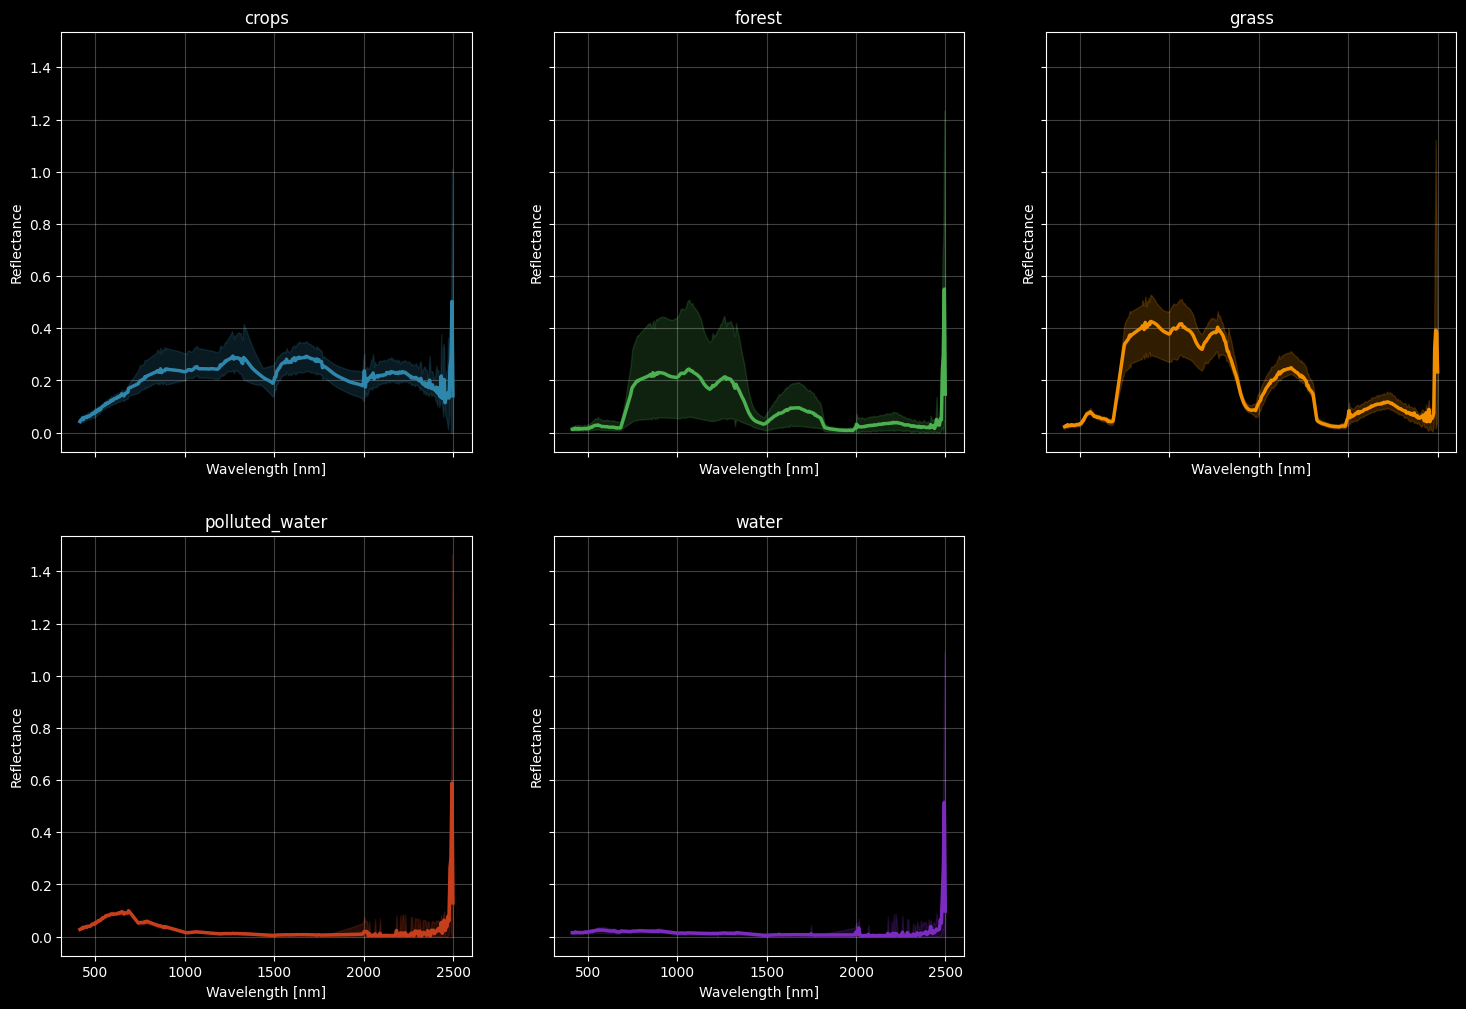

In [4]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

merged_path = Path("dataset/merged.csv")

with merged_path.open(newline="", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)
    data_rows = list(reader)

wavelengths = np.array([float(value) for value in header[1:]])
types = sorted({row[0] for row in data_rows})
colors = ["#2E86AB", "#4CAF50", "#F18F01", "#C73E1D", "#7B2CBF", "#00897B"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, type_name, color in zip(axes, types, colors):
    type_rows = [row[1:] for row in data_rows if row[0] == type_name]
    type_array = np.array(type_rows, dtype=float)

    mean_values = type_array.mean(axis=0)
    min_values = type_array.min(axis=0)
    max_values = type_array.max(axis=0)

    ax.plot(wavelengths, mean_values, color=color, linewidth=2.5)
    ax.fill_between(wavelengths, min_values, max_values, color=color, alpha=0.2)
    ax.set_title(type_name)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Reflectance")

for ax in axes[len(types):]:
    ax.axis("off")
